In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
import datetime
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, BatchNormalization, Dropout, Dense
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
!mkdir ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
! kaggle datasets list -s ham10000

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 5, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.10/dist-packages/kaggle/__init__.py", line 7, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.10/dist-packages/kaggle/api/kaggle_api_extended.py", line 398, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method.


In [ ]:
! kaggle datasets download -d kmader/skin-cancer-mnist-ham10000


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.19G/5.20G [01:03<00:00, 170MB/s]
100% 5.20G/5.20G [01:03<00:00, 88.2MB/s]


In [ ]:
!mkdir skin-cancer-mnist-ham10000
!unzip /content/skin-cancer-mnist-ham10000.zip -d skin-cancer-mnist-ham10000

Streaming output truncated to the last 5000 lines.
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: skin-cancer-mnist-ham10000/ham1000

In [ ]:
df = pd.read_csv('../content/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv')
df = df.sample(frac = 1) # randomize the data
data = df.iloc[:,:-1] # extract the pixel data
labels = df.iloc[:,-1:] # extract the corresponding labels
df.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
6964,192,160,176,192,161,179,192,161,183,192,...,189,158,167,186,154,159,186,156,165,4
7013,159,145,159,160,145,160,162,148,163,161,...,157,134,145,156,129,142,156,132,143,4
5756,221,152,165,224,157,168,230,169,181,227,...,211,156,161,212,153,160,209,152,158,4
8885,189,145,126,200,158,143,202,163,148,202,...,206,167,147,203,166,144,201,164,141,4
4880,207,97,120,209,101,123,209,102,122,211,...,212,134,126,207,128,120,206,128,118,4


In [ ]:
labels.head(30)

,label
6964,4
7013,4
5756,4
8885,4
4880,4
5132,4
4007,4
5977,4
7169,4
7227,4


<ipython-input-11-408b727002ac>:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(type_of_cancer)


[Text(0, 0, 'akiec'),
 Text(1, 0, 'df'),
 Text(2, 0, 'bkl'),
 Text(3, 0, 'mel'),
 Text(4, 0, 'nv'),
 Text(5, 0, 'vasc'),
 Text(6, 0, 'bcc')]

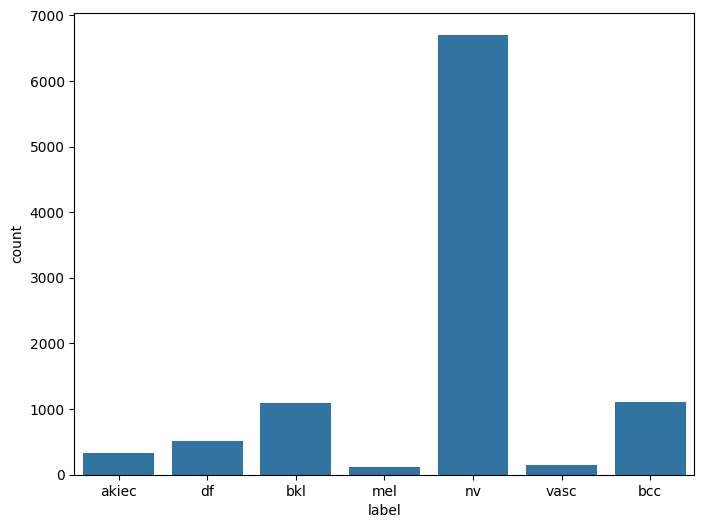

In [ ]:
type_of_cancer = ['akiec','df','bkl','mel','nv','vasc','bcc']
counts = list(labels.value_counts())
plt.figure(figsize = (8,6))
ax = sns.countplot(x='label', data=df)
ax.set_xticklabels(type_of_cancer)

In [ ]:
df = df.sort_values('label') # Sorting the data according to the labels
df = df.reset_index()
df


,index,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,9961,196,167,174,202,173,181,205,180,192,...,127,91,95,171,132,140,170,129,140,0
1,9996,78,47,58,125,79,90,149,96,105,...,179,140,150,173,131,148,166,128,142,0
2,9944,176,172,180,176,170,174,176,165,163,...,186,173,175,182,170,170,183,174,179,0
3,9749,179,123,105,191,138,123,199,146,133,...,173,123,120,154,101,86,143,93,83,0
4,9975,159,124,118,164,130,127,168,138,142,...,139,107,115,143,110,114,134,106,115,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,1811,3,2,3,7,4,6,9,5,7,...,134,117,137,127,111,131,80,63,81,6
10011,1461,65,41,35,26,11,8,91,70,68,...,36,17,16,64,40,34,61,36,30,6
10012,1725,72,51,44,107,82,76,133,110,102,...,150,114,116,136,107,107,108,80,80,6
10013,2007,163,150,168,163,147,161,163,142,151,...,128,110,117,149,134,146,148,135,152,6


In [ ]:
index0 = df[df['label'] == 0].index.values
index1 = df[df['label'] == 1].index.values
index2 = df[df['label'] == 2].index.values
index3 = df[df['label'] == 3].index.values
index5 = df[df['label'] == 5].index.values
index6 = df[df['label'] == 6].index.values


In [ ]:
df0 = df.iloc[int(min(index0)):int(max(index0)+1)]
df1 = df.iloc[int(min(index1)):int(max(index1)+1)]
df2 = df.iloc[int(min(index2)):int(max(index2)+1)]
df3 = df.iloc[int(min(index3)):int(max(index3)+1)]
df5 = df.iloc[int(min(index5)):int(max(index5)+1)]
df6 = df.iloc[int(min(index6)):int(max(index6)+1)]


In [ ]:
import pandas as pd

df_index0 = pd.concat([df0]*18, ignore_index = True)
df_index1 = pd.concat([df1]*16, ignore_index = True)
df_index2 = pd.concat([df2]*6, ignore_index = True)
df_index3 = pd.concat([df3]*53, ignore_index = True)
df_index5 = pd.concat([df5]*46, ignore_index = True)
df_index6 = pd.concat([df6]*6, ignore_index = True)

frames = [df, df_index0, df_index1, df_index2, df_index3, df_index5, df_index6]


In [ ]:
# Concatenating all the feature dataframes to form the final dataframe
final_df = pd.concat(frames)
final_df.drop('index', inplace = True, axis = 1)
final_df = final_df.sample(frac = 1)
data = final_df.iloc[:,:-1]
labels = final_df.iloc[:,-1:]

<ipython-input-18-408b727002ac>:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(type_of_cancer)


[Text(0, 0, 'akiec'),
 Text(1, 0, 'df'),
 Text(2, 0, 'bkl'),
 Text(3, 0, 'mel'),
 Text(4, 0, 'nv'),
 Text(5, 0, 'vasc'),
 Text(6, 0, 'bcc')]

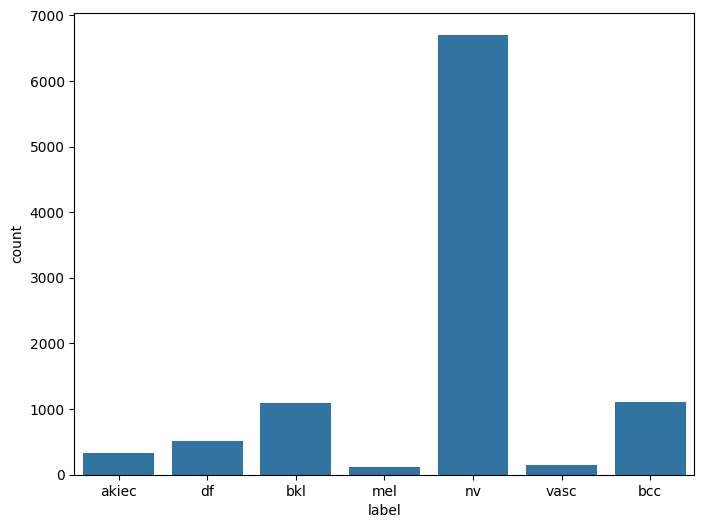

In [ ]:
type_of_cancer = ['akiec','df','bkl','mel','nv','vasc','bcc']
counts = list(labels.value_counts())
plt.figure(figsize = (8,6))
ax = sns.countplot(x='label', data=df)
ax.set_xticklabels(type_of_cancer)


In [ ]:
X = np.array(data)
Y = np.array(labels)

In [ ]:
X = X.reshape(-1,28,28,3)

print( X.shape)
print( Y.shape)

(50024, 28, 28, 3)
(50024, 1)


In [ ]:
X = (X-np.mean(X))/np.std(X)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

print( X_train.shape)
print( X_test.shape)
print( Y_train.shape)
print( Y_test.shape)

(40019, 28, 28, 3)
(10005, 28, 28, 3)
(40019, 1)
(10005, 1)


In [ ]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                  rotation_range = 10,
                                  width_shift_range = 0.2,
                                  height_shift_range = 0.2,
                                  shear_range = 0.2,
                                  horizontal_flip = True,
                                  vertical_flip = True,
                                  fill_mode = 'nearest')
train_datagen.fit(X_train)

test_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen.fit(X_test)

train_data = train_datagen.flow(X_train, Y_train, batch_size = 64)
test_data = test_datagen.flow(X_test, Y_test, batch_size = 64)


In [ ]:
model = Sequential([

    Conv2D(16, kernel_size = (3,3), input_shape = (28, 28, 3), activation = 'relu', padding = 'same'),
    Conv2D(32, kernel_size = (3,3), activation = 'relu'),
    MaxPool2D(pool_size = (2,2)),

    Conv2D(32, kernel_size = (3,3), activation = 'relu', padding = 'same'),
    Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    MaxPool2D(pool_size = (2,2), padding = 'same'),

    Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    Conv2D(64, kernel_size = (3,3), activation = 'relu', padding = 'same'),
    MaxPool2D(pool_size = (2,2), padding = 'same'),

    Flatten(),

    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(7, activation='softmax')]
)

In [ ]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            filepath='Cancer_model.keras',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

optimizer = tf.keras.optimizers.Adam(learning_rate = 0.00075,
                                    beta_1 = 0.9,
                                    beta_2 = 0.999,
                                    epsilon = 1e-8)


In [ ]:
model.compile(optimizer = optimizer,
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 16)        448       
                                                                 
 conv2d_1 (Conv2D)           (None, 26, 26, 32)        4640      
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 13, 13, 32)        9248      
                                                                 
 conv2d_3 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                   

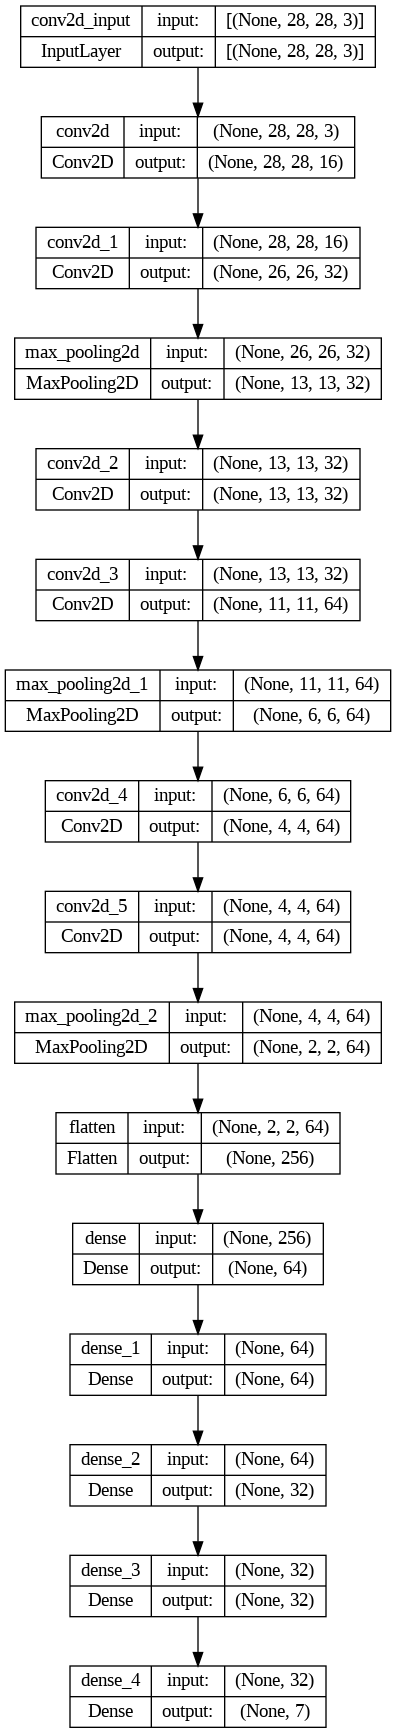

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)


In [ ]:
epochs = 20

history = model.fit(X_train,
                    Y_train,
                    validation_split=0.2,
                    batch_size = 64,
                    epochs = epochs,
                    callbacks=[learning_rate_reduction])


Epoch 1/20
501/501 [==============================] - 74s 141ms/step - loss: 1.3380 - accuracy: 0.4611 - val_loss: 1.0081 - val_accuracy: 0.6066 - lr: 7.5000e-04
Epoch 2/20
501/501 [==============================] - 69s 137ms/step - loss: 0.8275 - accuracy: 0.6831 - val_loss: 0.6462 - val_accuracy: 0.7700 - lr: 7.5000e-04
Epoch 3/20
501/501 [==============================] - 67s 133ms/step - loss: 0.5405 - accuracy: 0.7963 - val_loss: 0.4262 - val_accuracy: 0.8387 - lr: 7.5000e-04
Epoch 4/20
501/501 [==============================] - 68s 136ms/step - loss: 0.3643 - accuracy: 0.8622 - val_loss: 0.3129 - val_accuracy: 0.8834 - lr: 7.5000e-04
Epoch 5/20
501/501 [==============================] - 65s 131ms/step - loss: 0.2685 - accuracy: 0.8974 - val_loss: 0.3166 - val_accuracy: 0.8827 - lr: 7.5000e-04
Epoch 6/20
501/501 [==============================] - 67s 134ms/step - loss: 0.2145 - accuracy: 0.9194 - val_loss: 0.2437 - val_accuracy: 0.9068 - lr: 7.5000e-04
Epoch 7/20
501/501 [========

In [ ]:
model_acc_test = model.evaluate(X_test, Y_test, verbose=0)[1]
print("the test model accuracy =",model_acc_test * 100)

the test model accuracy = 97.17141389846802


In [ ]:
model_acc_train = model.evaluate(X_train, Y_train, verbose=0)[1]
print("the train model accuracy =",model_acc_train * 100)

the train model accuracy = 98.77058267593384


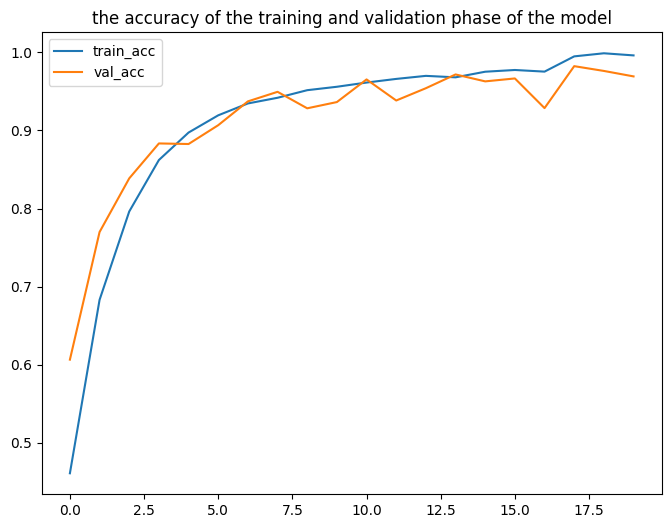

In [ ]:
ACC = history.history['accuracy']
VAL_ACC = history.history['val_accuracy']

plt.figure(figsize=(8,6))
plt.title("the accuracy of the training and validation phase of the model")
plt.plot(ACC, label = 'train_acc')
plt.plot(VAL_ACC, label = 'val_acc')
plt.legend()

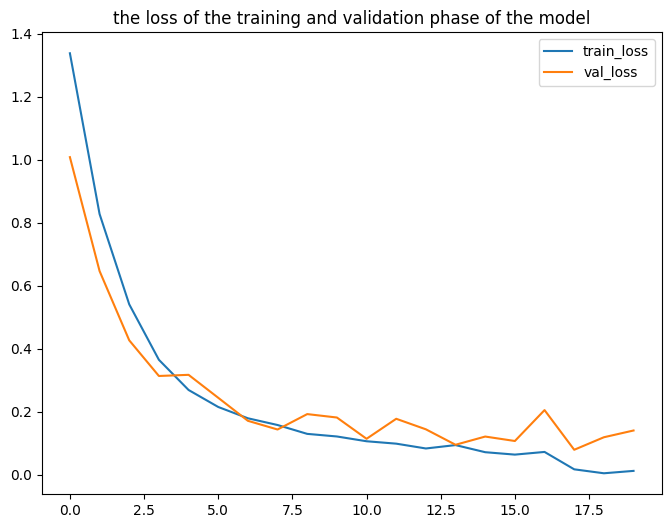

In [ ]:
LOSS = history.history['loss']
VAL_LOSS = history.history['val_loss']

plt.figure(figsize=(8,6))
plt.title("the loss of the training and validation phase of the model")
plt.plot(LOSS, label = 'train_loss')
plt.plot(VAL_LOSS, label = 'val_loss')
plt.legend()

313/313 [==============================] - 6s 19ms/step


<Axes: title={'center': 'the confusion matrix of the model in the train'}>

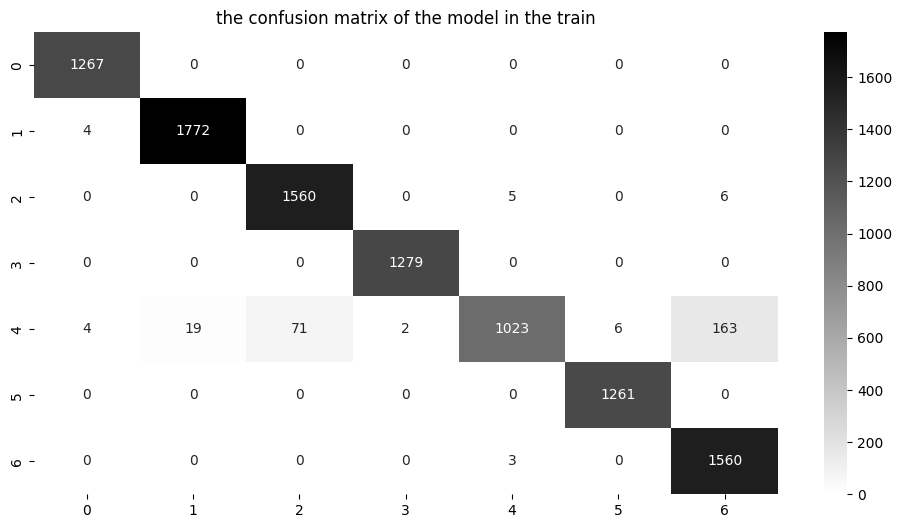

In [ ]:
Y_true = np.array(Y_test)

Y_pred = model.predict(X_test)
Y_pred = np.array(list(map(lambda x: np.argmax(x), Y_pred)))

cm1 = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(12, 6))
plt.title('the confusion matrix of the model in the train')
sns.heatmap(cm1, annot = True, fmt = 'g' ,vmin = 0, cmap = 'binary')


In [ ]:
model = load_model('Cancer_model.keras')